# 05_efficientnet_encoder.ipynb

## EfficientNet-B3 Echo Encoder

Develop an ImageNet-pretrained
EfficientNet-B3 encoder for cardiac
echo feature learning.

Objectives:

- pretrained backbone loading
- architecture inspection
- encoder preparation
- forward validation

In [1]:
import torch
import torch.nn as nn
from torchvision import models
from torchsummary import summary

## Environment Setup

Reuse notebook-04 pipeline.

This provides:

- datasets
- dataloaders
- preprocessing
- GPU setup

Device: cuda
True
True
True
FileList Shape : (10030, 9)
Tracings Shape : (425010, 6)


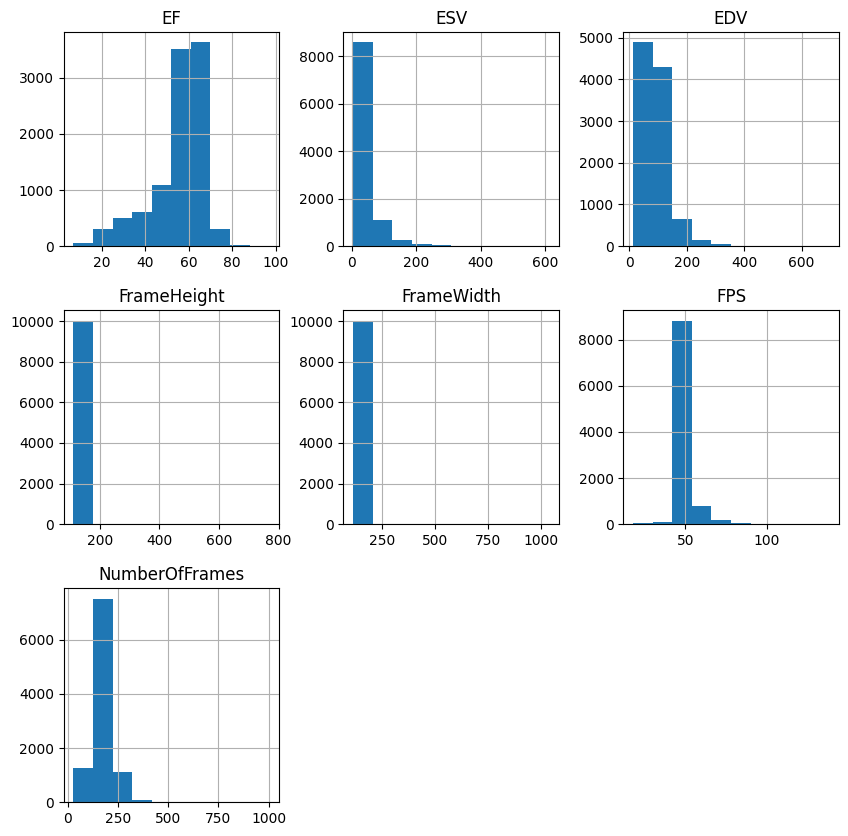

Metadata validation successful.


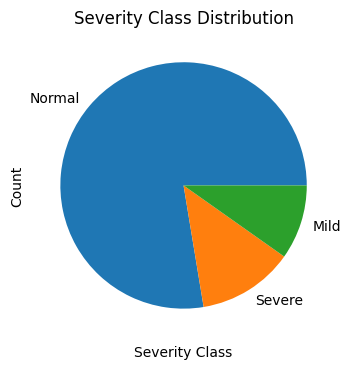

          EF         EDV         ESV Severity  SeverityID
0  78.498406   69.210534   14.881368   Normal           0
1  59.101988   98.742884   40.383876   Normal           0
2  62.363798   37.909734   14.267784   Normal           0
3  54.545097   72.914210   33.143084   Normal           0
4  24.887742  169.855024  127.581945   Severe           2
0X100009310A3BD7FC
Frame
46    21
61    21
Name: count, dtype: int64
{'area': 1221.3694052999126, 'perimeter': 256.9544765235363, 'major_axis': 62.02481460571289, 'minor_axis': 30.620874404907227, 'aspect_ratio': 2.025572874241634, 'compactness': 0.23245801484813056}


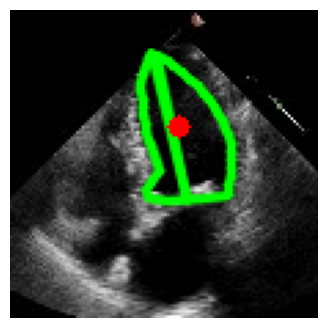

Tensor Shape : torch.Size([3, 224, 224])
Tensor Type  : torch.float32
Tracings sample:
                 FileName         X1         Y1         X2         Y2  Frame
0  0X100009310A3BD7FC.avi  51.260417  15.348958  64.932292  69.125000     46
1  0X100009310A3BD7FC.avi  50.037611  17.167841  53.367222  16.321330     46
2  0X100009310A3BD7FC.avi  49.157378  20.407629  57.090549  18.390722     46
Unique videos in tracings: 10025
Before Filtering: 10030
After Filtering: 10024
Dataset Length: 10024
Returned Keys:
dict_keys(['video', 'ef', 'edv', 'esv', 'severity', 'video_name', 'split'])
Video Shape: torch.Size([2, 3, 224, 224])
Tensor Type: torch.float32
EF Value: 78.49840597
EDV: 69.21053366
ESV: 14.88136797
Severity ID: 0
Video Name: 0X100009310A3BD7FC
Dataset Split: VAL


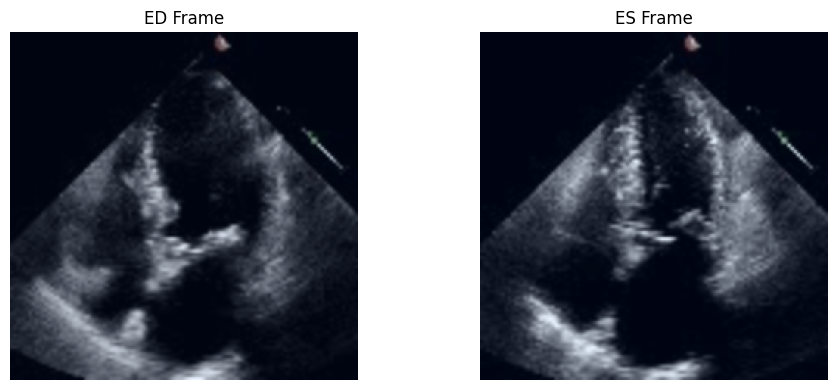

Video: 0X140A0F27BE9116F5
Frame
74    21
91    21
Name: count, dtype: int64
ED Frame: 74
ES Frame: 91


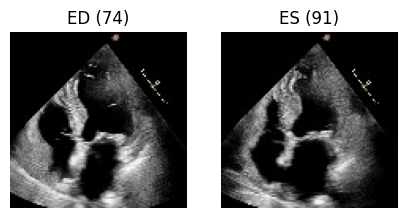

5015
5734
4650
417
9230
9918
294
5023
1766
4195
2289
1189
108
7587
857
8159
3111
4863
9270
851


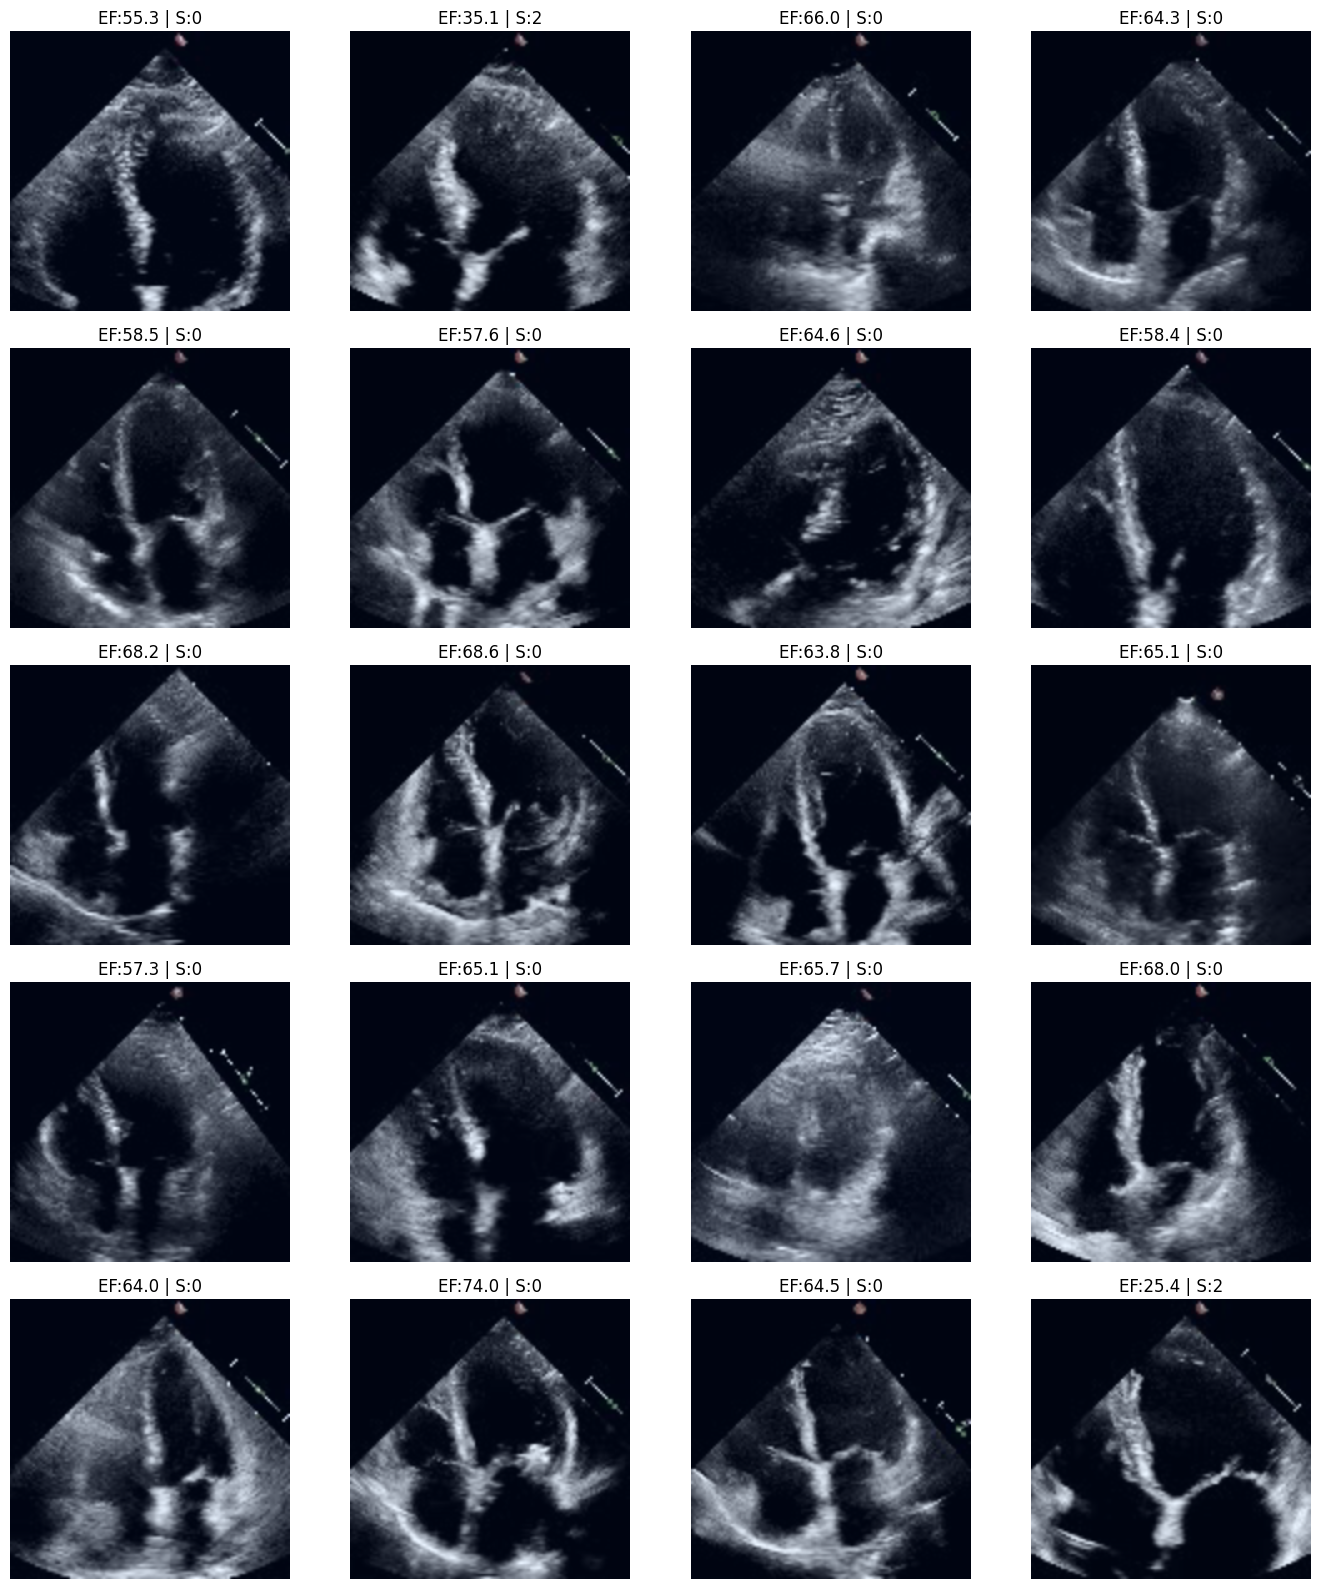


03_preprocessing.ipynb completed successfully.
<class '__main__.EchoDataset'>
<function train_transform at 0x719e8479d3a0>
/home/vasanth/projects/cardiac_vr_project/data/EchoNet-Dynamic/FileList.csv
/home/vasanth/projects/cardiac_vr_project/data/EchoNet-Dynamic/Videos
cuda
Tracings Shape: (425010, 6)
                 FileName         X1         Y1         X2         Y2  Frame
0  0X100009310A3BD7FC.avi  51.260417  15.348958  64.932292  69.125000     46
1  0X100009310A3BD7FC.avi  50.037611  17.167841  53.367222  16.321330     46
2  0X100009310A3BD7FC.avi  49.157378  20.407629  57.090549  18.390722     46
FileList Shape: (10030, 9)
TRAIN: 7465
VAL: 1288
TEST: 1277


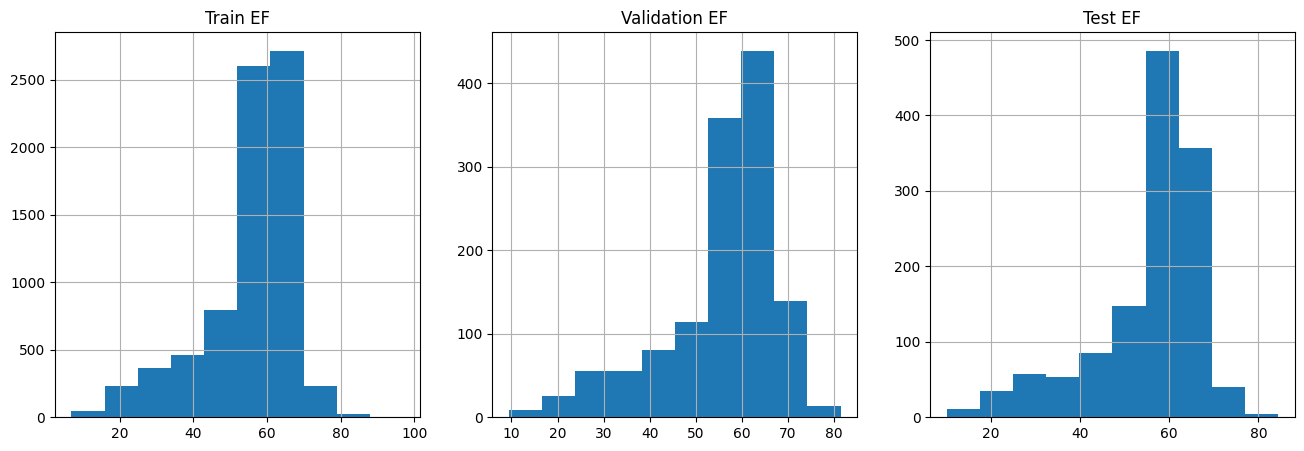

Train severity distribution:
Severity
Normal    5793
Severe     948
Mild       724
Name: count, dtype: int64

Val severity distribution:
Severity
Normal    999
Severe    156
Mild      133
Name: count, dtype: int64
Train EF stats:
count    7465.00
mean       55.78
std        12.41
min         6.91
25%        51.66
50%        59.28
75%        63.99
max        96.97
Name: EF, dtype: float64

Val EF stats:
count    1288.00
mean       55.82
std        12.31
min         9.48
25%        51.54
50%        59.33
75%        64.14
max        81.42
Name: EF, dtype: float64

EF mean : 55.78
EF std  : 12.41
CFG updated with actual EF stats.
Before Filtering: 7465
After Filtering: 7460
Before Filtering: 1288
After Filtering: 1288
Before Filtering: 1277
After Filtering: 1276
Train Dataset: 7460
Validation Dataset: 1288
Test Dataset: 1276
['FileName', 'EF', 'ESV', 'EDV', 'FrameHeight', 'FrameWidth', 'FPS', 'NumberOfFrames', 'Split', 'Severity', 'SeverityID']
<class 'dict'>
dict_keys(['video', 'ef', 'edv

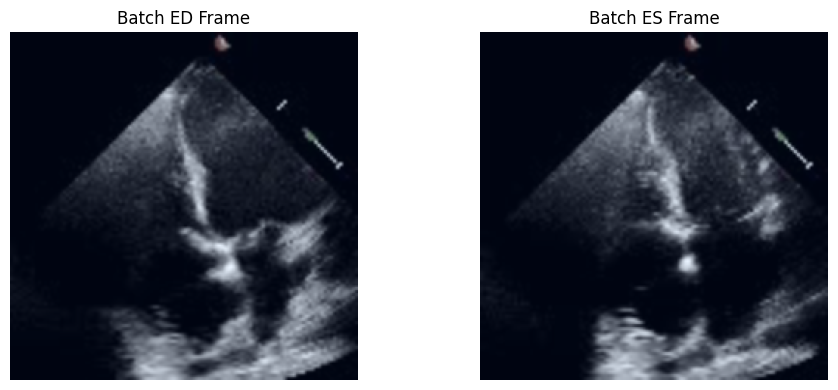

video -> cuda:0 | torch.Size([16, 2, 3, 224, 224])
ef -> cuda:0 | torch.Size([16])
edv -> cuda:0 | torch.Size([16])
esv -> cuda:0 | torch.Size([16])
severity -> cuda:0 | torch.Size([16])
Batch Time: 1.19 sec
Manual Batch: 1.21 sec
Batch EF — min: 34.0 max: 69.3 mean: 55.3
EF range valid.
torch.Size([2, 3, 224, 224])


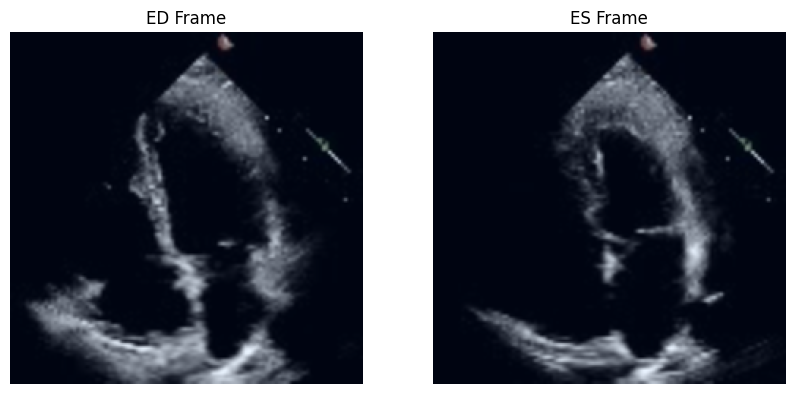

Nonzero Pixels: 20086
Total Pixels: 301056
Min: -2.1179039478302
Max: 2.552854299545288
Mean: -1.6084949970245361
Std: 0.7576591968536377
torch.Size([16, 2, 3, 224, 224])


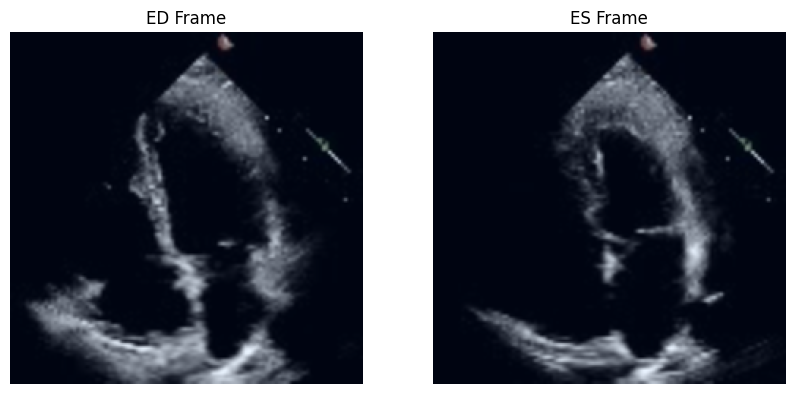


===== 04 PIPELINE SUMMARY =====
Train   : 7460 samples | 467 batches
Val     : 1288 samples | 81 batches
Test    : 1276 samples | 80 batches
Batch shape : torch.Size([16, 2, 3, 224, 224])
Keys        : ['video', 'ef', 'edv', 'esv', 'severity', 'video_name', 'split']

04_dataset_pipeline.ipynb executed successfully.


In [2]:
%run "./04_dataset_pipeline.ipynb"

In [3]:
print("DEVICE:",DEVICE)

DEVICE: cuda


## EfficientNet Backbone Loading

Load pretrained EfficientNet-B3
from torchvision.

In [4]:
from torchvision.models import EfficientNet_B3_Weights

efficientnet = models.efficientnet_b3(
    weights=EfficientNet_B3_Weights.IMAGENET1K_V1
)

In [5]:
efficientnet = efficientnet.to(DEVICE)

In [6]:
print(efficientnet)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
            (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
        

In [7]:
total_params = sum(p.numel() for p in efficientnet.parameters())

trainable_params = sum(p.numel() for p in efficientnet.parameters() if p.requires_grad)

print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

Total Parameters: 12,233,232
Trainable Parameters: 12,233,232


In [8]:
summary(efficientnet,input_size=(3,224,224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 40, 112, 112]           1,080
       BatchNorm2d-2         [-1, 40, 112, 112]              80
              SiLU-3         [-1, 40, 112, 112]               0
            Conv2d-4         [-1, 40, 112, 112]             360
       BatchNorm2d-5         [-1, 40, 112, 112]              80
              SiLU-6         [-1, 40, 112, 112]               0
 AdaptiveAvgPool2d-7             [-1, 40, 1, 1]               0
            Conv2d-8             [-1, 10, 1, 1]             410
              SiLU-9             [-1, 10, 1, 1]               0
           Conv2d-10             [-1, 40, 1, 1]             440
          Sigmoid-11             [-1, 40, 1, 1]               0
SqueezeExcitation-12         [-1, 40, 112, 112]               0
           Conv2d-13         [-1, 24, 112, 112]             960
      BatchNorm2d-14         [-1, 24, 1

In [9]:
print(efficientnet.classifier)

Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1536, out_features=1000, bias=True)
)


In [10]:
sample = train_dataset[0]
video = sample["video"]
ed_frame = video[0].unsqueeze(0).to(DEVICE)

with torch.no_grad():
    out = efficientnet(ed_frame)

print("Output Shape:",out.shape)

Output Shape: torch.Size([1, 1000])


## Encoder Construction

Convert EfficientNet-B3 into a
feature encoder.

Steps:

- remove classification head
- keep convolutional backbone
- global pooling
- projection layer
- embedding generation

In [11]:
print(efficientnet.features)
print()
print(efficientnet.avgpool)
print()
print(efficientnet.classifier)

Sequential(
  (0): Conv2dNormActivation(
    (0): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): SiLU(inplace=True)
  )
  (1): Sequential(
    (0): MBConv(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
          (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (2): SiLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
          (activation): SiLU(inplace=True)
          (scale_activation): Sigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(40, 24, kernel_size

In [12]:
class EchoEncoder(nn.Module):

    def __init__(self):
        super().__init__()
        backbone = models.efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)
        self.features = backbone.features
        
        # Freeze whole backbone
        for param in self.features.parameters():
            param.requires_grad = False
        
        # Unfreeze only last EfficientNet block
        for param in self.features[-1].parameters():
            param.requires_grad = True
            
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.projection = nn.Sequential(
                              nn.Linear(1536,512),
                              nn.ReLU(),
                              nn.Dropout(0.3)
                          )

    def forward(self,x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x,1)
        x = self.projection(x)
        return x

In [13]:
encoder = EchoEncoder()
encoder = encoder.to(DEVICE)
print(encoder)

EchoEncoder(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
            (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
         

In [14]:
total_params = sum(p.numel() for p in encoder.parameters())
trainable_params = sum(p.numel() for p in encoder.parameters() if p.requires_grad)
print("Total:",f"{total_params:,}")
print("Trainable:",f"{trainable_params:,}")

Total: 11,483,176
Trainable: 1,379,840


In [15]:
sample = train_dataset[0]
video = sample["video"]
ed_frame = video[0].unsqueeze(0).to(DEVICE)

with torch.no_grad():
    embedding = encoder(ed_frame)

print("Embedding Shape:",embedding.shape)

Embedding Shape: torch.Size([1, 512])


In [16]:
batch = next(
    iter(train_loader)
)
batch_video = batch["video"]
ed_batch = batch_video[:,0].to(DEVICE)

with torch.no_grad():
    batch_embedding = encoder(ed_batch)

print("Batch Input Shape:",ed_batch.shape)
print("Batch Embedding Shape:",batch_embedding.shape)

Batch Input Shape: torch.Size([16, 3, 224, 224])
Batch Embedding Shape: torch.Size([16, 512])


In [17]:
print("Min:",batch_embedding.min().item())
print("Max:",batch_embedding.max().item())
print("Mean:",batch_embedding.mean().item())

Min: 0.0
Max: 0.6897211074829102
Mean: 0.054975513368844986


## Dual-Frame Feature Encoding

Encode:

- End Diastolic (ED) frame
- End Systolic (ES) frame

Generate separate embeddings and
combine them into a unified
cardiac representation.

In [18]:
batch = next(
    iter(train_loader)
)

videos = batch["video"]

print("Original Shape:",videos.shape)
ed_frames = videos[:,0]
es_frames = videos[:,1]
print("ED Shape:",ed_frames.shape)
print("ES Shape:",es_frames.shape)

Original Shape: torch.Size([16, 2, 3, 224, 224])
ED Shape: torch.Size([16, 3, 224, 224])
ES Shape: torch.Size([16, 3, 224, 224])


In [19]:
ed_frames = ed_frames.to(DEVICE)
es_frames = es_frames.to(DEVICE)

with torch.no_grad():
    ed_embedding = encoder(ed_frames)
    es_embedding = encoder(es_frames)

print("ED Embedding:",ed_embedding.shape)
print("ES Embedding:",es_embedding.shape)

ED Embedding: torch.Size([16, 512])
ES Embedding: torch.Size([16, 512])


In [20]:
combined_embedding = torch.cat([ed_embedding,es_embedding],dim=1)
print("Combined Shape:",combined_embedding.shape)

Combined Shape: torch.Size([16, 1024])


In [21]:
print("Min:",combined_embedding.min().item())
print("Max:",combined_embedding.max().item())
print("Mean:",combined_embedding.mean().item())
print("Std:",combined_embedding.std().item())

Min: 0.0
Max: 0.8362592458724976
Mean: 0.05508141964673996
Std: 0.10553343594074249


In [22]:
print("EF:",batch["ef"][:5])
print()
print("Severity:",batch["severity"][:5])

EF: tensor([59.1020, 62.3638, 54.5451, 36.5737, 33.9917], dtype=torch.float64)

Severity: tensor([0, 0, 0, 2, 2])


In [23]:
print(
    f"""
Pipeline Summary

Input Video:
{videos.shape}

ED Features:
{ed_embedding.shape}

ES Features:
{es_embedding.shape}

Combined:
{combined_embedding.shape}
"""
)


Pipeline Summary

Input Video:
torch.Size([16, 2, 3, 224, 224])

ED Features:
torch.Size([16, 512])

ES Features:
torch.Size([16, 512])

Combined:
torch.Size([16, 1024])



## EF Regression Model

Build a simple regression model
on top of the echo encoder.

Objective:

Predict:

- Ejection Fraction (EF)

In [24]:
class EchoRegressor(nn.Module):

    def __init__(self):
        super().__init__()
        self.encoder = EchoEncoder()
        self.head = nn.Linear(1024,1)

    def forward(self,ed_frames,es_frames):

        ed_feat = self.encoder(ed_frames)
        es_feat = self.encoder(es_frames)
        features = torch.cat([ed_feat,es_feat],dim=1)
        ef_pred = self.head(features)
        return torch.clamp(
                    ef_pred.squeeze(-1),
                    min=0,
                    max=100
                )

In [25]:
model = EchoRegressor()
model = model.to(DEVICE)
print(model)

EchoRegressor(
  (encoder): EchoEncoder(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
              (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=Tru

In [26]:
def get_contour(batch, device):
    return batch["contour_feats"].to(device)

In [27]:
batch     = next(iter(train_loader))
videos    = batch["video"]
ed_frames = videos[:, 0].to(DEVICE)
es_frames = videos[:, 1].to(DEVICE)

with torch.no_grad():
    preds = model(ed_frames, es_frames)

print("Prediction Shape:", preds.shape)
print("Sample preds:", preds[:5])

Prediction Shape: torch.Size([16])
Sample preds: tensor([0., 0., 0., 0., 0.], device='cuda:0')


In [28]:
targets = batch["ef"].float().to(DEVICE)
print("Predictions:", preds[:5])
print("Targets    :", targets[:5])

Predictions: tensor([0., 0., 0., 0., 0.], device='cuda:0')
Targets    : tensor([59.1020, 62.3638, 54.5451, 36.5737, 33.9917], device='cuda:0')


In [29]:
criterion = nn.SmoothL1Loss(beta=5.0)
loss = criterion(preds / 100.0, targets / 100.0)
print("Loss (normalized):", loss.item())
print("MAE (EF pp)      :", loss.item() * 100)

Loss (normalized): 0.03171207010746002
MAE (EF pp)      : 3.171207010746002


In [30]:
model.train()
preds = model(ed_frames, es_frames)
loss  = criterion(preds / 100.0, targets / 100.0)
loss.backward()
print("Backward pass OK")
print("Loss:", loss.item())

Backward pass OK
Loss: 0.03170740604400635


In [31]:
for name,param in model.named_parameters():
    if param.grad is not None:
        print(name,param.grad.norm().item())
        break

encoder.features.8.0.weight 0.00011486828589113429


## Mini Training Step Validation

Validate:

- optimizer setup
- gradient clearing
- forward pass
- loss computation
- parameter update

In [32]:
optimizer = torch.optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=5e-5,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)
print(optimizer)

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 5e-05
    maximize: False
    weight_decay: 0.0001
)


In [33]:
batch = next(
    iter(train_loader)
)
videos = batch["video"]
ed_frames = videos[:,0].to(DEVICE)
es_frames = videos[:,1].to(DEVICE)
targets = batch["ef"].float().to(DEVICE)

In [34]:
model.train()
optimizer.zero_grad()
preds = model(ed_frames, es_frames)
loss  = criterion(preds / 100.0, targets / 100.0)
loss.backward()
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
optimizer.step()
print("MAE Loss (normalized):", loss.item())
print("MAE (EF pp)          :", loss.item() * 100)

MAE Loss (normalized): 0.03170698136091232
MAE (EF pp)          : 3.1706981360912323


In [37]:
before = model.head.weight.clone()
optimizer.zero_grad()
preds = model(ed_frames, es_frames)
loss  = criterion(preds / 100.0, targets / 100.0)
loss.backward()
optimizer.step()
after  = model.head.weight
change = (after - before).abs().mean()
print("Average Weight Change:", change.item())

Average Weight Change: 3.2762563932919875e-05


In [38]:
model.eval()
with torch.no_grad():
    preds = model(ed_frames, es_frames)
print(preds[:5])

tensor([0., 0., 0., 0., 0.], device='cuda:0')


## Epoch Training Validation

Run a short multi-epoch sanity check to
observe loss variation and verify that
the model is learning.

In [39]:
LOAD_CHECKPOINT = True
CHECKPOINT_PATH = (
    MODEL_DIR /"Frozen_e1.pth"
)

start_epoch = 0
train_losses = []
val_losses = []

if LOAD_CHECKPOINT and CHECKPOINT_PATH.exists():
    checkpoint = torch.load(
        CHECKPOINT_PATH,
        map_location=DEVICE
    )

    model.load_state_dict(checkpoint["model_state_dict"])
    # optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch"]
    train_losses = checkpoint.get("train_losses",[])
    val_losses = checkpoint.get("val_losses",[])
    
    print(f"Checkpoint Loaded — Resume from Epoch {start_epoch}")

else:
    print("Fresh Training Start")

print(f"Starting Epoch {start_epoch}")
print("train losses: ",train_losses)
print("validation losses: ",val_losses)

Checkpoint Loaded — Resume from Epoch 19
Starting Epoch 19
train losses:  [3177.043701171875, 405.09376732542376, 78.50548637194092, 55.23219778399906, 33.728371192352164, 22.52436151494306, 17.103148182148086, 27.588408866326866, 24.053270313418142, 13.5587598133904, 10.304821136421515, 9.588585444640296, 12.077058445462834, 12.520723308179312, 18.409872355246698, 11.500033897301881, 9.991513876384024, 0.7944294826249239, 1.19445270051027]
validation losses:  [115.15181054009332, 119.77248975965712, 4.672084870161833, 4.601518672189595]


In [38]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

model.eval()

all_preds = []
all_targets = []
all_video_names = []

with torch.no_grad():

    for batch in val_loader:

        videos = batch["video"]

        ed_frames = videos[:, 0].to(DEVICE)
        es_frames = videos[:, 1].to(DEVICE)

        targets = batch["ef"].float().to(DEVICE)
        preds = model(
            ed_frames,
            es_frames,
        )

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_targets.extend(
            targets.cpu().numpy()
        )

        all_video_names.extend(
            batch["video_name"]
        )

mse = mean_squared_error(
    all_targets,
    all_preds
)

mae = mean_absolute_error(
    all_targets,
    all_preds
)

r2 = r2_score(
    all_targets,
    all_preds
)

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

print("\nPrediction Range:")
print(f"Pred Min: {np.min(all_preds):.4f}")
print(f"Pred Max: {np.max(all_preds):.4f}")

print(f"Target Min: {np.min(all_targets):.4f}")
print(f"Target Max: {np.max(all_targets):.4f}")

print("\nSample Predictions vs Targets:\n")

for i in range(min(10, len(all_preds))):

    print(
        f"Pred: {all_preds[i]:.2f}"
        f" | Target: {all_targets[i]:.2f}"
    )

MSE: 109.6442
MAE: 6.6498
R² Score: 0.2759

Prediction Range:
Pred Min: 13.1447
Pred Max: 100.0000
Target Min: 9.4824
Target Max: 81.4151

Sample Predictions vs Targets:

Pred: 70.57 | Target: 78.50
Pred: 23.69 | Target: 24.89
Pred: 64.65 | Target: 69.20
Pred: 50.78 | Target: 62.37
Pred: 55.11 | Target: 58.86
Pred: 62.82 | Target: 64.79
Pred: 48.27 | Target: 32.80
Pred: 46.38 | Target: 37.65
Pred: 49.45 | Target: 31.98
Pred: 55.42 | Target: 62.79


In [ ]:
print("val_losses: " ,val_losses)
print("train_losses: ",train_losses)

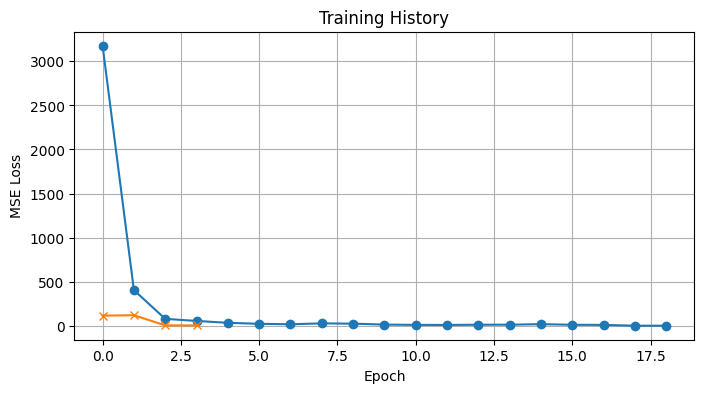

In [39]:
plt.figure(figsize=(8,4))

plt.plot(
    train_losses,
    marker='o'
)

plt.plot(
    val_losses,
    marker='x'
)

plt.xlabel("Epoch")

plt.ylabel("MSE Loss")

plt.title("Training History")

plt.grid(True)

plt.show()

  MSE      : 109.6442
  MAE      : 6.6498
  R2 Score : 0.2759

Pred  → min:13.14  max:100.00  mean:56.23  std:11.05
Target→ min:9.48  max:81.42  mean:55.82  std:12.31


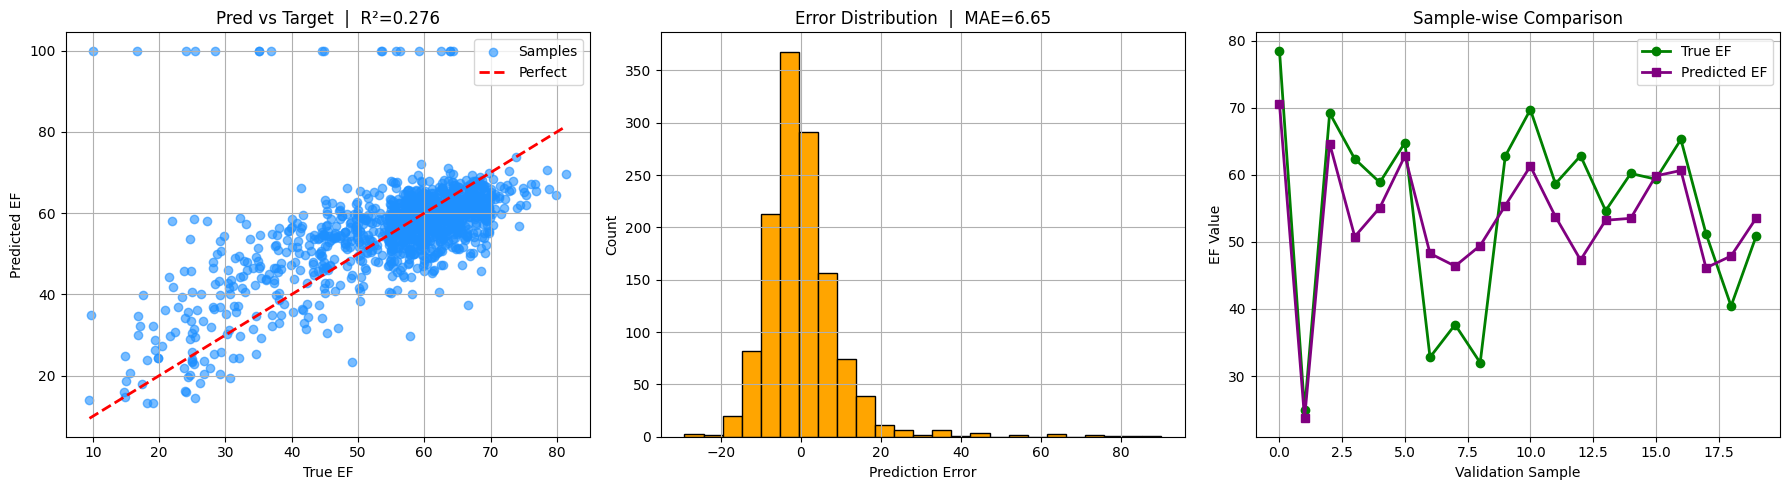


Top 10 Worst Predictions:
  Video:0X22E91BA7334F8292  Pred:29.74  Target:57.86  Err:-28.12
  Video:0X2DF0CD09785D2C10  Pred:53.71  Target:24.69  Err:29.02
  Video:0X37C99A3FE9350BA0  Pred:37.48  Target:66.55  Err:-29.07
  Video:0X73E9825196EB26F9  Pred:58.12  Target:27.18  Err:30.94
  Video:0X6D06CFF7DED256F  Pred:58.66  Target:25.27  Err:33.40
  Video:0X1D00424C7EBCCA52  Pred:100.00  Target:64.29  Err:35.71
  Video:0X3B2972B434AE6A78  Pred:100.00  Target:63.96  Err:36.04
  Video:0X35995BE8BB3A6D42  Pred:100.00  Target:63.92  Err:36.08
  Video:0X4D4EB3BBA778944F  Pred:58.06  Target:21.87  Err:36.19
  Video:0X39207AF594BF77D7  Pred:100.00  Target:62.51  Err:37.49
  Video:0X1ED182EA95B3349E  Pred:100.00  Target:59.18  Err:40.82
  Video:0X3B9FBD87EE113D62  Pred:100.00  Target:56.30  Err:43.70
  Video:0X46E335EDE6F8E5AD  Pred:100.00  Target:55.70  Err:44.30
  Video:0X26BCB772A8DD9BEC  Pred:100.00  Target:53.59  Err:46.41
  Video:0X3A3085150FD2D6E8  Pred:100.00  Target:53.54  Err:46.46
  V

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ── METRICS ────────────────────────────────────────────────
preds_np  = np.array(all_preds)
targets_np = np.array(all_targets)

mse = mean_squared_error(targets_np, preds_np)
mae = mean_absolute_error(targets_np, preds_np)
r2  = r2_score(targets_np, preds_np)

print("=" * 35)
print(f"  MSE      : {mse:.4f}")
print(f"  MAE      : {mae:.4f}")
print(f"  R2 Score : {r2:.4f}")
print("=" * 35)

print(f"\nPred  → min:{preds_np.min():.2f}  max:{preds_np.max():.2f}  mean:{preds_np.mean():.2f}  std:{preds_np.std():.2f}")
print(f"Target→ min:{targets_np.min():.2f}  max:{targets_np.max():.2f}  mean:{targets_np.mean():.2f}  std:{targets_np.std():.2f}")

# ── PLOTS ──────────────────────────────────────────────────
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# 1. Pred vs Target scatter
ax[0].scatter(targets_np, preds_np, color='dodgerblue', alpha=0.6, label='Samples')
ax[0].plot([targets_np.min(), targets_np.max()],
           [targets_np.min(), targets_np.max()],
           color='red', linestyle='--', linewidth=2, label='Perfect')
ax[0].set_title(f"Pred vs Target  |  R²={r2:.3f}")
ax[0].set_xlabel("True EF")
ax[0].set_ylabel("Predicted EF")
ax[0].legend()
ax[0].grid(True)

# 2. Error distribution
errors = preds_np - targets_np
ax[1].hist(errors, bins=25, color='orange', edgecolor='black')
ax[1].set_title(f"Error Distribution  |  MAE={mae:.2f}")
ax[1].set_xlabel("Prediction Error")
ax[1].set_ylabel("Count")
ax[1].grid(True)

# 3. Sample-wise comparison (first 20)
n = min(20, len(targets_np))
ax[2].plot(targets_np[:n], marker='o', color='green', linewidth=2, label='True EF')
ax[2].plot(preds_np[:n],   marker='s', color='purple', linewidth=2, label='Predicted EF')
ax[2].set_title("Sample-wise Comparison")
ax[2].set_xlabel("Validation Sample")
ax[2].set_ylabel("EF Value")
ax[2].legend()
ax[2].grid(True)

plt.tight_layout()
plt.show()

# ── WORST CASES ────────────────────────────────────────────
worst_idx = np.argsort(np.abs(errors))[-25:]
print("\nTop 10 Worst Predictions:")
for idx in worst_idx:
    print(f"  Video:{all_video_names[idx]}  Pred:{preds_np[idx]:.2f}  Target:{targets_np[idx]:.2f}  Err:{errors[idx]:.2f}")

In [42]:
epoch = len(train_losses)
torch.save(
    {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_losses": train_losses,
        "val_losses": val_losses,
    },
    MODEL_DIR / f"final_model.pth"
)
print(f"Checkpoint saved → epoch_{epoch}.pth")

Checkpoint saved → epoch_19.pth


# Notebook-05 Summary

Completed:

✓ EfficientNet-B3 loading

✓ pretrained backbone inspection

✓ EchoEncoder construction

✓ ED / ES encoding

✓ feature fusion

✓ EF regression head

✓ MAE loss integration

✓ optimizer validation

✓ gradient validation

✓ checkpoint save / reload

The visual encoder subsystem
is now operational and ready
for full training experiments.